# Exploratory Data Analysis (EDA) Report

This notebook provides a complete summary of the Exploratory Data Analysis performed on the Titanic dataset.

The report combines findings from dataset understanding, data inspection, data quality assessment, statistical analysis, distribution analysis, outlier analysis, relationship analysis, visualizations, and business insights.

The purpose of this notebook is to document the important findings and identify potential data problems that should be addressed during the next preprocessing stage. Complete preprocessing is not performed in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1. Dataset Overview

### Concept

Dataset overview provides a basic understanding of the dataset before analyzing it in detail.

### Dataset Source

The Titanic dataset contains information about passengers who travelled on the Titanic.

### Dataset Size

The dataset size is identified using the number of rows and columns.

### Features

The dataset contains passenger-related features such as passenger class, name, sex, age, family information, ticket details, fare, cabin, and embarkation port.

### Target

The `Survived` column is the target variable. It represents whether a passenger survived (`1`) or did not survive (`0`).

### Domain

The dataset belongs to the passenger transportation and survival analysis domain.

### Interpretation

Understanding the dataset structure helps us identify the available features and the Machine Learning problem.

### Insight

The Titanic dataset represents a binary classification problem because the target variable contains two classes.

### AI/ML Relevance

Dataset overview is important because it helps identify the target variable, feature types, and the overall problem before building a Machine Learning model.

In [2]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nTarget Variable: Survived")
print("Problem Type: Binary Classification")

Dataset Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Target Variable: Survived
Problem Type: Binary Classification


## 2. Data Quality Findings

### Concept

Data quality assessment identifies problems that may affect analysis and Machine Learning model performance.

### Findings

The main data quality areas examined are:

- Missing values
- Duplicate records
- Invalid values
- Incorrect data types

### Interpretation

These issues should be identified and documented before preprocessing.

### Insight

Poor data quality can lead to incorrect analysis and unreliable Machine Learning results.

### AI/ML Relevance

Data quality assessment provides the foundation for the next preprocessing stage.

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


## 3. Missing Values

### Concept

Missing values occur when information is not available for one or more observations.

### Findings

Important columns should be checked to determine where missing values occur and how many values are missing.

### Interpretation

Missing values can affect statistical analysis and may cause errors when training some Machine Learning models.

### Insight

Columns with a large number of missing values may require a different treatment compared with columns containing only a small number of missing values.

### AI/ML Relevance

Possible future treatments include removing records, imputing values, using statistical methods, or considering whether a feature should be retained.

At this stage, the missing values are only identified and documented.

In [4]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

print(missing_summary[missing_summary["Missing Count"] > 0].round(2))

          Missing Count  Missing Percentage
Age                 177               19.87
Cabin               687               77.10
Embarked              2                0.22


## 4. Duplicate Records

### Concept

Duplicate records are rows that appear more than once in a dataset.

### Interpretation

Completely duplicated rows may represent repeated data entries and should be investigated.

### Insight

Not every similar record is necessarily a duplicate. Passengers may share similar characteristics while still representing different individuals.

### AI/ML Relevance

True duplicate records can create bias by giving repeated observations additional influence during model training.

At this stage, duplicates are identified but not automatically removed.

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of Completely Duplicated Rows:", duplicate_count)

Number of Completely Duplicated Rows: 0


## 5. Invalid Values and Data-Type Issues

### Concept

Invalid values are values that do not logically fit the meaning of a variable. Data-type issues occur when a column is stored in an inappropriate format.

### Example

Age should not normally contain negative values, and passenger class should contain only valid class categories.

### Interpretation

Potential invalid values should be investigated before preprocessing decisions are made.

### Insight

The dataset should be checked for impossible numerical values and unexpected categorical values.

### AI/ML Relevance

Incorrect values and inappropriate data types can affect feature engineering, encoding, statistical analysis, and model performance.

In [6]:
print("Negative Age Values:", (df["Age"] < 0).sum())
print("Negative Fare Values:", (df["Fare"] < 0).sum())

print("\nPassenger Class Values:")
print(sorted(df["Pclass"].dropna().unique()))

print("\nSex Categories:")
print(df["Sex"].value_counts())

print("\nEmbarked Categories:")
print(df["Embarked"].value_counts(dropna=False))

Negative Age Values: 0
Negative Fare Values: 0

Passenger Class Values:
[np.int64(1), np.int64(2), np.int64(3)]

Sex Categories:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked Categories:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


## 6. Statistical Findings

### Concept

Statistical analysis summarizes the numerical features using measures of central tendency and dispersion.

### Central Tendency

The mean and median help identify the center of a numerical distribution.

### Dispersion

The standard deviation, variance, minimum, maximum, and range help measure the spread of the data.

### Distribution

Skewness helps us understand whether a distribution is symmetric or skewed.

### Interpretation

Different numerical variables can have different centers, spreads, and distribution shapes.

### Insight

Statistical findings provide a compact summary of important numerical features before preprocessing.

### AI/ML Relevance

Understanding numerical feature behavior helps identify possible transformations, scaling requirements, and outlier-related concerns.

In [7]:
numerical_cols = ["Age", "SibSp", "Parch", "Fare"]

stats_summary = df[numerical_cols].describe().T

stats_summary["Variance"] = df[numerical_cols].var()
stats_summary["Skewness"] = df[numerical_cols].skew()

print(stats_summary.round(2))

       count   mean    std   min    25%    50%   75%     max  Variance  \
Age    714.0  29.70  14.53  0.42  20.12  28.00  38.0   80.00    211.02   
SibSp  891.0   0.52   1.10  0.00   0.00   0.00   1.0    8.00      1.22   
Parch  891.0   0.38   0.81  0.00   0.00   0.00   0.0    6.00      0.65   
Fare   891.0  32.20  49.69  0.00   7.91  14.45  31.0  512.33   2469.44   

       Skewness  
Age        0.39  
SibSp      3.70  
Parch      2.75  
Fare       4.79  


## 7. Distribution Findings

### Concept

Distribution analysis examines the shape, center, spread, skewness, and possible extreme values of numerical features.

### Findings

Features such as `Age` and `Fare` are useful for examining different distribution patterns.

### Interpretation

A symmetric distribution has a relatively balanced shape, while a skewed distribution has a longer tail on one side.

### Insight

Highly skewed variables may require additional attention during preprocessing.

### AI/ML Relevance

Feature transformation may be considered for strongly skewed numerical features, depending on the Machine Learning model and analysis requirements.

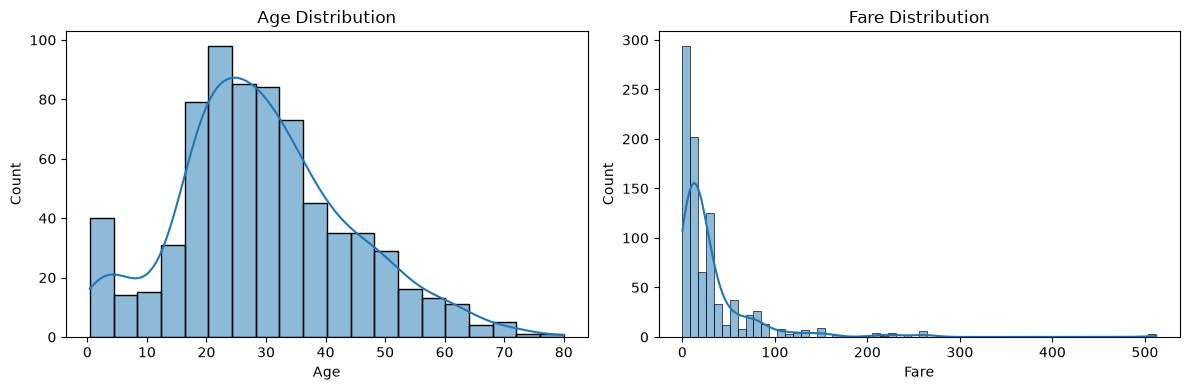

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Age"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["Fare"], kde=True, ax=axes[1])
axes[1].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

## 8. Outlier Findings

### Concept

Outliers are observations that are unusually far from most other observations.

### Findings

Numerical variables such as `Fare` can contain extreme values.

### Interpretation

An extreme value is not automatically a data error. It may represent a genuine but unusual observation.

### Insight

Outliers should be investigated before deciding whether they should be retained, transformed, capped, or removed.

### AI/ML Relevance

Outliers can strongly influence some statistical methods and Machine Learning algorithms.

Therefore, outliers should be documented and investigated rather than automatically removed.

In [9]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Potential Fare Outliers:", len(fare_outliers))

Potential Fare Outliers: 116


## 9. Relationship Findings

### Concept

Relationship analysis examines how features are associated with each other and with the target variable.

### Correlations

Numerical correlations help identify positive, negative, and weak linear relationships.

### Feature Relationships

Categorical and numerical features can also be compared with the target variable.

### Important Patterns

Previous analysis indicates that features such as passenger class and sex show meaningful relationships with survival.

### Interpretation

A relationship between two variables does not automatically mean that one variable causes the other.

### Insight

Important relationships can help identify useful predictive features and possible feature interactions.

### AI/ML Relevance

Relationship analysis supports feature selection and helps identify potential multicollinearity or feature redundancy.

          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00


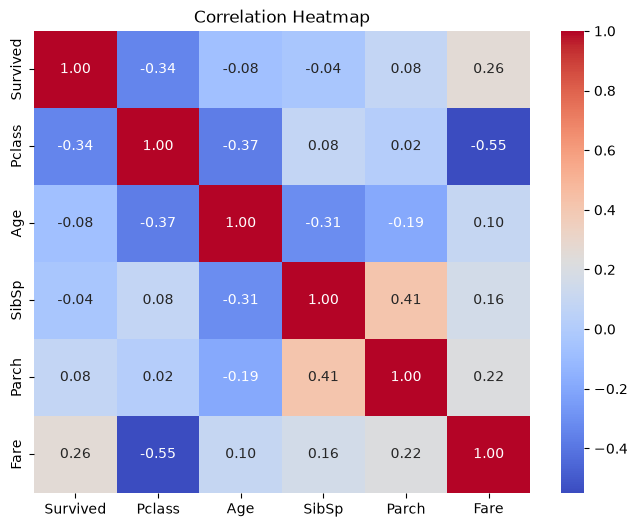

In [10]:
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

correlation_matrix = df[corr_cols].corr()

print(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 10. Important Feature Relationships

### Concept

Important feature relationships help us understand which passenger characteristics are associated with the target variable.

### Findings

The analysis of previous notebooks showed important relationships between:

- Sex and survival
- Passenger class and survival
- Fare and passenger class
- Age and survival
- Family-related features and survival

### Interpretation

Some features provide more useful information when they are analyzed together rather than individually.

### Insight

Gender and passenger class appear to be important passenger characteristics associated with survival.

### AI/ML Relevance

Feature relationships can guide feature selection and feature engineering during the preprocessing and model-building stages.

In [11]:
print("Survival Rate by Sex:")
print((df.groupby("Sex")["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby("Pclass")["Survived"].mean() * 100).round(2))

Survival Rate by Sex:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


## 11. Visualization Findings

### Concept

Visualizations make patterns and relationships easier to understand than numerical summaries alone.

### Important Visual Insights

The main visualizations from the EDA showed:

- The age distribution of passengers.
- The presence of extreme values in the fare variable.
- Different passenger counts across categorical groups.
- Differences in survival across gender and passenger class.
- Relationships between numerical features.
- Correlations among important numerical variables.

### Interpretation

Each visualization was selected to answer a specific question about the dataset rather than simply creating graphs.

### Insight

Visual analysis supports the statistical findings and provides a clearer understanding of important patterns and anomalies.

### AI/ML Relevance

Visualizations help identify potential preprocessing needs and useful features before model development.

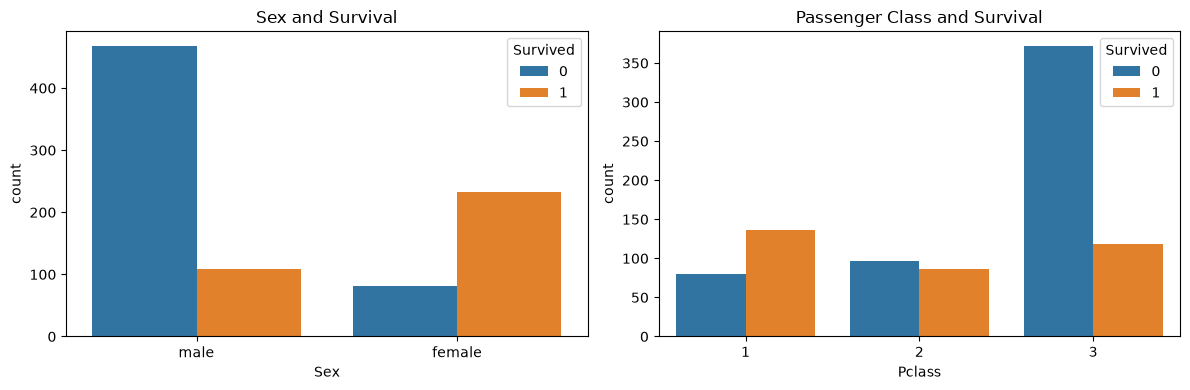

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0])
axes[0].set_title("Sex and Survival")

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[1])
axes[1].set_title("Passenger Class and Survival")

plt.tight_layout()
plt.show()

## 12. Potential Data Problems

### Concept

Potential data problems are issues identified during EDA that may need to be addressed during preprocessing.

### Identified Issues

The Titanic dataset may require attention in the following areas:

- Missing values in some columns.
- Possible extreme values or outliers.
- Categorical variables that require encoding.
- Numerical variables with different scales.
- Highly skewed numerical distributions.
- High-cardinality or identifier-like columns such as `Name` and `Ticket`.
- Columns that may require feature engineering or transformation.

### Interpretation

These issues are documented now so that preprocessing decisions can be made systematically in the next sprint.

### Insight

The purpose of EDA is to understand the problems before changing the data.

### AI/ML Relevance

Identifying problems before preprocessing helps avoid unnecessary transformations and supports better data preparation decisions.

In [13]:
print("High-Cardinality Features:")

for col in ["Name", "Ticket", "Cabin"]:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nNumerical Feature Ranges:")
print(df[["Age", "Fare", "SibSp", "Parch"]].agg(["min", "max"]))

High-Cardinality Features:
Name: 891 unique values
Ticket: 681 unique values
Cabin: 147 unique values

Numerical Feature Ranges:
       Age      Fare  SibSp  Parch
min   0.42    0.0000      0      0
max  80.00  512.3292      8      6


## 13. Recommendations for the Next Preprocessing Sprint

Based on the EDA findings, the following actions should be considered during preprocessing:

### 1. Missing-Value Treatment

Investigate suitable methods for handling missing values in features such as `Age`, `Cabin`, and `Embarked`.

### 2. Outlier Treatment

Investigate unusual values before deciding whether they should be retained, transformed, capped, or removed.

### 3. Encoding

Convert categorical features into numerical representations suitable for Machine Learning models.

### 4. Scaling

Consider scaling numerical features when required by the selected Machine Learning algorithm.

### 5. Feature Transformation

Consider transformations for strongly skewed numerical features.

### 6. Feature Engineering

Create potentially useful features, such as family-related features, titles extracted from names, or grouped cabin information.

### 7. Data-Type Review

Ensure that each feature has an appropriate data type for analysis and Machine Learning.

### Important Note

These actions are recommendations only. The complete preprocessing is not performed in this EDA sprint.

In [14]:
recommendations = [
    "Investigate missing-value treatment",
    "Review potential outliers",
    "Encode categorical variables",
    "Consider numerical feature scaling",
    "Review skewed feature transformations",
    "Explore feature engineering",
    "Review data types"
]

print("Recommendations for the Next Preprocessing Sprint:\n")

for i, item in enumerate(recommendations, start=1):
    print(f"{i}. {item}")

Recommendations for the Next Preprocessing Sprint:

1. Investigate missing-value treatment
2. Review potential outliers
3. Encode categorical variables
4. Consider numerical feature scaling
5. Review skewed feature transformations
6. Explore feature engineering
7. Review data types


# Final EDA Report Conclusion

The Exploratory Data Analysis of the Titanic dataset provided a structured understanding of the dataset, its quality, statistical characteristics, distributions, outliers, feature relationships, and important visual patterns.

The dataset represents a binary classification problem where `Survived` is the target variable. The analysis identified important relationships involving features such as sex and passenger class, while also highlighting data quality and preprocessing concerns.

The main issues identified for the next stage include missing values, potential outliers, categorical encoding requirements, feature scaling considerations, skewed numerical distributions, high-cardinality features, and opportunities for feature engineering.

The purpose of this EDA sprint was to identify and document these findings. The complete preprocessing process should be performed separately during the next preprocessing stage.